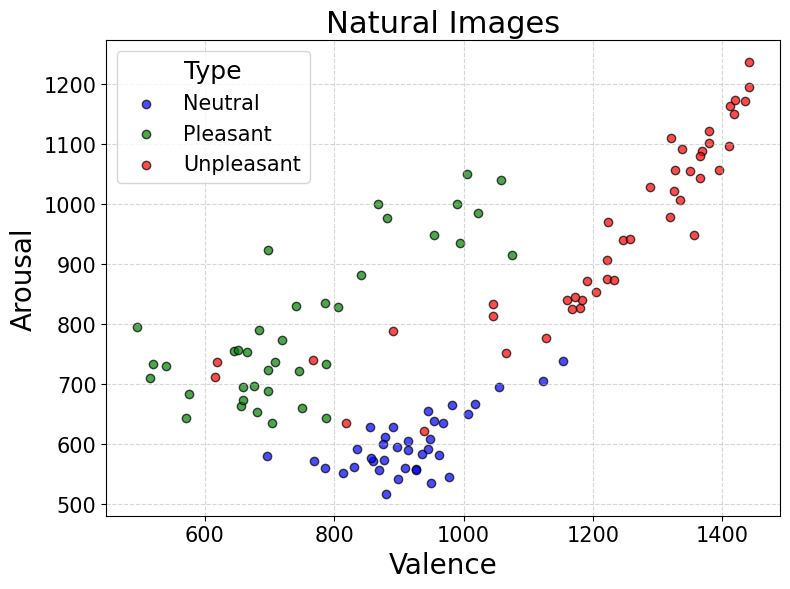

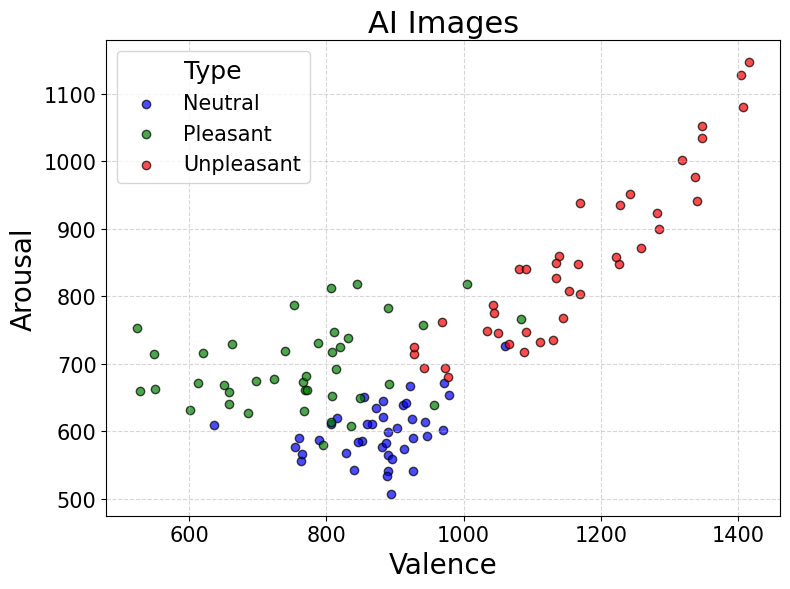

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ==== File paths ====
base_path = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\behavior"
master_file = f"{base_path}\\custom_master.xlsx"
ratings_file = f"{base_path}\\singlepictureratings_Sep9.xlsx"

# ==== Load master info ====
master = pd.read_excel(master_file)

# ==== Load Valence and Arousal sheets ====
valence = pd.read_excel(ratings_file, sheet_name='Valence')
arousal = pd.read_excel(ratings_file, sheet_name='Arousal')

# ==== Merge both with master ====
valence_merged = valence.merge(master, left_on='Picture', right_on='id', how='left')
arousal_merged = arousal.merge(master, left_on='Picture', right_on='id', how='left')

# ==== Average across participants ====
valence_merged['Valence_mean'] = valence_merged.iloc[:, 1:-3].mean(axis=1)
arousal_merged['Arousal_mean'] = arousal_merged.iloc[:, 1:-3].mean(axis=1)

# ==== Combine Valence & Arousal ====
merged = valence_merged[['Picture', 'Valence_mean', 'type', 'modality']].merge(
    arousal_merged[['Picture', 'Arousal_mean']],
    on='Picture'
)

# ==== Define color map ====
color_map = {'Pleasant': 'green', 'Neutral': 'blue', 'Unpleasant': 'red'}

# ==== Plot for AI and Natural separately ====
for modality in merged['modality'].unique():
    subset = merged[merged['modality'] == modality]
    plt.figure(figsize=(8, 6))
    for emo_type, group in subset.groupby('type'):
        plt.scatter(group['Valence_mean'], group['Arousal_mean'],
                    label=emo_type, color=color_map.get(emo_type, 'gray'),
                    alpha=0.7, edgecolor='k')
    plt.title(f'{modality} Images', fontsize=22)
    plt.xlabel('Valence', fontsize=20)
    plt.ylabel('Arousal', fontsize=20)
    plt.yticks(fontsize=15)
    plt.xticks(fontsize=15)
    plt.legend(title='Type', fontsize=15, title_fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\yujunchen\nilearn_data\fsl
Atlas saved to: C:\MRIcroGL\Resources\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz
Label file saved to: C:\MRIcroGL\Resources\HarvardOxford-sub-maxprob-thr25-1mm.txt

Number of regions: 22

Labels:
0: Background
1: Left Cerebral White Matter
2: Left Cerebral Cortex
3: Left Lateral Ventricle
4: Left Thalamus
5: Left Caudate
6: Left Putamen
7: Left Pallidum
8: Brain-Stem
9: Left Hippocampus
10: Left Amygdala
11: Left Accumbens
12: Right Cerebral White Matter
13: Right Cerebral Cortex
14: Right Lateral Ventricle
15: Right Thalamus
16: Right Caudate
17: Right Putamen
18: Right Pallidum
19: Right Hippocampus
20: Right Amygdala
21: Right Accumbens


In [5]:
import nibabel as nib
import os

# Path to your atlas file
atlas_path = r'C:\MRIcroGL\Resources\atlas\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz'
output_path = r'C:\MRIcroGL\Resources\atlas\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz'

# Load the NIfTI file
img = nib.load(atlas_path)

# Get the header and set the intent to "Labels"
header = img.header.copy()
header.set_intent('label', name='HarvardOxford Subcortical')
# Intent code 1002 = Labels
header['intent_code'] = 1002

# Create new image with modified header
new_img = nib.Nifti1Image(img.get_fdata(), img.affine, header)

# Save the modified file
nib.save(new_img, output_path)

print(f"✓ Atlas file updated with 'Labels' intent")
print(f"✓ Saved to: {output_path}")
print("\nNow reload the atlas in MRIcroGL:")
print("1. Close the current atlas overlay")
print("2. File → Add Atlas → Select the .nii.gz file again")

✓ Atlas file updated with 'Labels' intent
✓ Saved to: C:\MRIcroGL\Resources\atlas\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz

Now reload the atlas in MRIcroGL:
1. Close the current atlas overlay
2. File → Add Atlas → Select the .nii.gz file again


In [1]:
import nibabel as nib
import numpy as np
import pandas as pd

# File paths
roi_path = r'N:\Experimental_Data\yujunchen\projects\Lihan_amygdala\Extend_amyg\Threshold_0_Extend_1.img'
atlas_path = r'C:\MRIcroGL\Resources\atlas\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz'

# Atlas labels
atlas_labels = {
    0: "Background",
    1: "Left Cerebral White Matter",
    2: "Left Cerebral Cortex",
    3: "Left Lateral Ventricle",
    4: "Left Thalamus",
    5: "Left Caudate",
    6: "Left Putamen",
    7: "Left Pallidum",
    8: "Brain-Stem",
    9: "Left Hippocampus",
    10: "Left Amygdala",
    11: "Left Accumbens",
    12: "Right Cerebral White Matter",
    13: "Right Cerebral Cortex",
    14: "Right Lateral Ventricle",
    15: "Right Thalamus",
    16: "Right Caudate",
    17: "Right Putamen",
    18: "Right Pallidum",
    19: "Right Hippocampus",
    20: "Right Amygdala",
    21: "Right Accumbens"
}

print("Loading files...")
# Load the ROI image
roi_img = nib.load(roi_path)
roi_data = roi_img.get_fdata()

# Load the atlas
atlas_img = nib.load(atlas_path)
atlas_data = atlas_img.get_fdata()

print(f"ROI shape: {roi_data.shape}")
print(f"Atlas shape: {atlas_data.shape}")
print(f"ROI affine:\n{roi_img.affine}")
print(f"Atlas affine:\n{atlas_img.affine}")

# Check if images are in the same space
if roi_data.shape != atlas_data.shape:
    print("\n⚠ WARNING: Images have different dimensions!")
    print("Attempting to resample ROI to atlas space...")
    
    from nilearn.image import resample_to_img
    roi_img_resampled = resample_to_img(roi_img, atlas_img, interpolation='nearest')
    roi_data = roi_img_resampled.get_fdata()
    print(f"Resampled ROI shape: {roi_data.shape}")

# Get non-zero voxels in the ROI (assuming ROI is binary or has threshold values)
roi_mask = roi_data > 0
total_roi_voxels = np.sum(roi_mask)

print(f"\n{'='*70}")
print(f"Total voxels in ROI: {total_roi_voxels}")
print(f"{'='*70}\n")

# Calculate overlap with each atlas region
overlap_results = []

for region_idx in range(1, 22):  # Skip background (0)
    # Get voxels belonging to this atlas region
    atlas_region_mask = atlas_data == region_idx
    
    # Calculate overlap
    overlap_mask = roi_mask & atlas_region_mask
    overlap_voxels = np.sum(overlap_mask)
    
    if overlap_voxels > 0:
        # Percentage of ROI voxels in this atlas region
        percentage_of_roi = (overlap_voxels / total_roi_voxels) * 100
        
        # Percentage of atlas region covered by ROI
        atlas_region_voxels = np.sum(atlas_region_mask)
        percentage_of_atlas_region = (overlap_voxels / atlas_region_voxels) * 100 if atlas_region_voxels > 0 else 0
        
        overlap_results.append({
            'Region_Index': region_idx,
            'Region_Name': atlas_labels[region_idx],
            'Overlap_Voxels': overlap_voxels,
            'Percentage_of_ROI': percentage_of_roi,
            'Atlas_Region_Total_Voxels': atlas_region_voxels,
            'Percentage_of_Atlas_Region': percentage_of_atlas_region
        })

# Create DataFrame and sort by overlap
df = pd.DataFrame(overlap_results)
df = df.sort_values('Overlap_Voxels', ascending=False)

# Display results
print("OVERLAP ANALYSIS RESULTS")
print("="*70)
print(f"\nRegions with overlap (sorted by number of overlapping voxels):\n")
print(df.to_string(index=False))

# Summary statistics
print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
print(f"Total ROI voxels: {total_roi_voxels}")
print(f"Number of atlas regions with overlap: {len(df)}")
print(f"Total overlapping voxels: {df['Overlap_Voxels'].sum()}")
print(f"Percentage of ROI with atlas overlap: {(df['Overlap_Voxels'].sum() / total_roi_voxels * 100):.2f}%")

# Top regions
if len(df) > 0:
    print(f"\nTop 3 overlapping regions:")
    for idx, row in df.head(3).iterrows():
        print(f"  {row['Region_Name']}: {row['Overlap_Voxels']} voxels ({row['Percentage_of_ROI']:.2f}% of ROI)")

# Save results to CSV
output_csv = r'N:\Experimental_Data\yujunchen\projects\Lihan_amygdala\Extend_amyg\overlap_analysis.csv'
df.to_csv(output_csv, index=False)
print(f"\n✓ Results saved to: {output_csv}")

# Create a detailed report
report_path = r'N:\Experimental_Data\yujunchen\projects\Lihan_amygdala\Extend_amyg\overlap_report.txt'
with open(report_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("ROI-ATLAS OVERLAP ANALYSIS REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(f"ROI File: {roi_path}\n")
    f.write(f"Atlas File: {atlas_path}\n")
    f.write(f"Total ROI voxels: {total_roi_voxels}\n\n")
    f.write("="*70 + "\n")
    f.write("DETAILED OVERLAP BY REGION\n")
    f.write("="*70 + "\n\n")
    
    for idx, row in df.iterrows():
        f.write(f"Region: {row['Region_Name']}\n")
        f.write(f"  - Overlapping voxels: {row['Overlap_Voxels']}\n")
        f.write(f"  - Percentage of ROI: {row['Percentage_of_ROI']:.2f}%\n")
        f.write(f"  - Percentage of atlas region: {row['Percentage_of_Atlas_Region']:.2f}%\n")
        f.write("\n")

print(f"✓ Detailed report saved to: {report_path}")

Loading files...
ROI shape: (53, 63, 46)
Atlas shape: (182, 218, 182)
ROI affine:
[[  -3.    0.    0.   78.]
 [   0.    3.    0. -112.]
 [   0.    0.    3.  -50.]
 [   0.    0.    0.    1.]]
Atlas affine:
[[   1.    0.    0.  -91.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]

⚠ WARNING: Images have different dimensions!
Attempting to resample ROI to atlas space...


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_3004\813280761.py:55: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  roi_img_resampled = resample_to_img(roi_img, atlas_img, interpolation='nearest')
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_3004\813280761.py:55: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  roi_img_resampled = resample_to_img(roi_img, atlas_img, interpolation='nearest')


Resampled ROI shape: (182, 218, 182)

Total voxels in ROI: 28998

OVERLAP ANALYSIS RESULTS

Regions with overlap (sorted by number of overlapping voxels):

 Region_Index                 Region_Name  Overlap_Voxels  Percentage_of_ROI  Atlas_Region_Total_Voxels  Percentage_of_Atlas_Region
            2        Left Cerebral Cortex            4922          16.973584                     512675                    0.960062
           13       Right Cerebral Cortex            4730          16.311470                     509101                    0.929089
            1  Left Cerebral White Matter            4097          14.128561                     249575                    1.641591
           12 Right Cerebral White Matter            3052          10.524864                     250063                    1.220492
           20              Right Amygdala            2834           9.773088                       2848                   99.508427
           10               Left Amygdala           